In [1]:
import numpy as np
import pandas as pd
import torch
import timesfm
import logging
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

logging.basicConfig(
    filename='TimesFM_SSMI_FineTuned_Decomposed_Kalman_v1_Metrics.log',
    level=logging.INFO,
    format='%(asctime)s %(levelname)s: %(message)s',
    force=True
)

CHECKPOINT_LOW = Path('./timesfm_ssmi_low_kalman_v1.pt')
CHECKPOINT_HIGH = Path('./timesfm_ssmi_high_kalman_v1.pt')

# Must match training config (finetune_timesfm_decomposed_kalman_v1.py)
KALMAN_PROCESS_NOISE = 0.1
KALMAN_MEASUREMENT_NOISE = 1.0


def kalman_decompose_context(y_context, process_noise=KALMAN_PROCESS_NOISE, measurement_noise=KALMAN_MEASUREMENT_NOISE):
    """One-pass causal scalar Kalman filter — identical to training-time decomposition."""
    y = np.asarray(y_context, dtype=float)
    q = float(process_noise)
    r = float(measurement_noise)

    x = float(y[0])
    p = 1.0
    low = np.zeros_like(y, dtype=float)

    for i, z in enumerate(y):
        p = p + q
        k = p / (p + r)
        x = x + k * (float(z) - x)
        p = (1.0 - k) * p
        low[i] = x

    high = y - low
    return low, high


def main():
    rmse_list = []
    mape_list = []
    pearson_list = []
    directional_hits = []
    try:
        # ========================
        # 1) Load SSMI test slice (post-2018)
        # ========================
        df = pd.read_csv('../../DataSets/trimmed/SSMI.csv', parse_dates=['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        test_df = df[df['Date'] >= pd.Timestamp('2018-01-01')].reset_index(drop=True)

        nan_count = int(test_df['Adj Close'].isna().sum())
        if nan_count > 0:
            test_df = test_df.copy()
            test_df['Adj Close'] = test_df['Adj Close'].ffill().bfill()
            logging.info(f'Forward-filled {nan_count} NaN values in test data')
            print(f'Forward-filled {nan_count} NaN values in test data')

        y = test_df['Adj Close'].values.astype(float)
        total_samples = len(y)
        logging.info(
            f"Test range: {test_df['Date'].iloc[0].date()} -> {test_df['Date'].iloc[-1].date()} ({total_samples} days)"
        )
        print(
            f"Test range: {test_df['Date'].iloc[0].date()} -> {test_df['Date'].iloc[-1].date()} ({total_samples} days)"
        )

        # ========================
        # 2) Sliding-window config (v1: NO normalization)
        # ========================
        context_window = 180
        forecast_horizon = 15
        step_size = 30
        num_segments = (total_samples - context_window) // step_size
        logging.info(f'Segments to evaluate: {num_segments}')

        # ========================
        # 3) Load two fine-tuned TimesFM models (low / high)
        # ========================
        tfm_low = timesfm.TimesFm(
            hparams=timesfm.TimesFmHparams(
                backend='cpu',
                per_core_batch_size=32,
                horizon_len=forecast_horizon,
                context_len=192,
            ),
            checkpoint=timesfm.TimesFmCheckpoint(
                huggingface_repo_id='google/timesfm-1.0-200m-pytorch',
            ),
        )
        tfm_low._model.load_state_dict(torch.load(str(CHECKPOINT_LOW), map_location='cpu'))
        tfm_low._model.eval()
        logging.info(f'Fine-tuned low-pass weights loaded from {CHECKPOINT_LOW}')
        print(f'Fine-tuned low-pass weights loaded from {CHECKPOINT_LOW}')

        tfm_high = timesfm.TimesFm(
            hparams=timesfm.TimesFmHparams(
                backend='cpu',
                per_core_batch_size=32,
                horizon_len=forecast_horizon,
                context_len=192,
            ),
            checkpoint=timesfm.TimesFmCheckpoint(
                huggingface_repo_id='google/timesfm-1.0-200m-pytorch',
            ),
        )
        tfm_high._model.load_state_dict(torch.load(str(CHECKPOINT_HIGH), map_location='cpu'))
        tfm_high._model.eval()
        logging.info(f'Fine-tuned high-pass weights loaded from {CHECKPOINT_HIGH}')
        print(f'Fine-tuned high-pass weights loaded from {CHECKPOINT_HIGH}')

        # ========================
        # 4) Sliding-window evaluation (v1: NO normalization)
        # ========================
        for segment in range(num_segments):
            start_context = segment * step_size
            end_context = start_context + context_window
            if end_context + forecast_horizon > total_samples:
                break

            y_context = y[start_context:end_context]
            y_true = y[end_context:end_context + forecast_horizon]

            context_low, context_high = kalman_decompose_context(y_context)

            point_forecast_low, _ = tfm_low.forecast([context_low], freq=[0])
            forecast_low = point_forecast_low[0][:forecast_horizon]

            point_forecast_high, _ = tfm_high.forecast([context_high], freq=[0])
            forecast_high = point_forecast_high[0][:forecast_horizon]

            combined_pred = forecast_low + forecast_high

            prev_anchor = np.concatenate([[y[end_context - 1]], y_true[:-1]])
            actual_direction = np.sign(y_true - prev_anchor)
            pred_direction = np.sign(combined_pred - prev_anchor)
            hits = (actual_direction == pred_direction).astype(int)
            directional_hits.extend(hits.tolist())

            rmse = np.sqrt(mean_squared_error(y_true, combined_pred))
            mape = mean_absolute_percentage_error(y_true, combined_pred) * 100
            r2 = pearsonr(y_true, combined_pred).statistic ** 2

            rmse_list.append(rmse)
            mape_list.append(mape)
            pearson_list.append(r2)

            segment_dir_acc = hits.mean() * 100
            logging.info(
                f'Segment {segment+1}/{num_segments}: RMSE={rmse:.4f}, MAPE={mape:.4f}%, R2={r2:.4f}, DirAcc={segment_dir_acc:.1f}%'
            )
            print(
                f'Segment {segment+1}/{num_segments} - RMSE: {rmse:.2f} | MAPE: {mape:.2f}% | R2: {r2:.4f} | Dir Acc: {segment_dir_acc:.1f}%'
            )

        # ========================
        # 5) Save results
        # ========================
        np.savez_compressed(
            'TimesFM_SSMI_FineTuned_Decomposed_Kalman_v1_Metrics.npz',
            rmse=np.array(rmse_list),
            mape=np.array(mape_list),
            pearson_coefficients=np.array(pearson_list),
            directional_hits=np.array(directional_hits),
            context_window=context_window,
            forecast_horizon=forecast_horizon,
            process_noise=KALMAN_PROCESS_NOISE,
            measurement_noise=KALMAN_MEASUREMENT_NOISE,
            num_segments=num_segments,
        )
        logging.info('Results saved to TimesFM_SSMI_FineTuned_Decomposed_Kalman_v1_Metrics.npz')

        # ========================
        # 6) Summary
        # ========================
        total_days = len(directional_hits)
        total_hits = sum(directional_hits)
        dir_acc_pct = (total_hits / total_days) * 100 if total_days else 0.0

        print('\n--- Median Metrics for Kalman-v1 Fine-Tuned TimesFM on SSMI (post-2018 test) ---')
        print(f'Median RMSE:          {np.median(rmse_list):.4f}')
        print(f'Median MAPE:          {np.median(mape_list):.4f}%')
        print(f'Median Pearson R²:    {np.median(pearson_list):.4f}')
        print(f'Directional Accuracy: {total_hits}/{total_days} days ({dir_acc_pct:.2f}%)')

    except Exception:
        logging.error('An error occurred.', exc_info=True)
        print('An error occurred. Check TimesFM_SSMI_FineTuned_Decomposed_Kalman_v1_Metrics.log for details.')
        try:
            np.savez_compressed(
                'partial_TimesFM_SSMI_FineTuned_Decomposed_Kalman_v1_Metrics.npz',
                rmse=np.array(rmse_list),
                mape=np.array(mape_list),
                pearson_coefficients=np.array(pearson_list),
                directional_hits=np.array(directional_hits),
            )
        except Exception:
            logging.error('Failed to save partial results.', exc_info=True)
    finally:
        logging.info('Forecasting run completed.')


if __name__ == '__main__':
    main()

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


Loaded PyTorch TimesFM, likely because python version is 3.11.5 (main, Sep 11 2023, 08:31:25) [Clang 14.0.6 ].


Forward-filled 7 NaN values in test data
Test range: 2018-01-03 -> 2021-05-17 (843 days)


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Fine-tuned low-pass weights loaded from timesfm_ssmi_low_kalman_v1.pt


...

Segment 18/22 - RMSE: 220.63 | MAPE: 1.95% | R2: 0.5453 | Dir Acc: 60.0%


Segment 19/22 - RMSE: 94.25 | MAPE: 0.81% | R2: 0.6500 | Dir Acc: 46.7%


Segment 20/22 - RMSE: 198.45 | MAPE: 1.65% | R2: 0.7585 | Dir Acc: 26.7%


Segment 21/22 - RMSE: 176.05 | MAPE: 1.38% | R2: 0.0334 | Dir Acc: 33.3%


Segment 22/22 - RMSE: 101.14 | MAPE: 0.74% | R2: 0.1756 | Dir Acc: 53.3%

--- Median Metrics for Kalman-v1 Fine-Tuned TimesFM on SSMI (post-2018 test) ---
Median RMSE:          166.3281
Median MAPE:          1.3768%
Median Pearson R²:    0.2875
Directional Accuracy: 175/330 days (53.03%)


## Backtesting

Translates the fine-tuned TimesFM directional signals (low-pass + high-pass, v1: ctx=180 / hor=15 / Kalman q=0.1 r=1.0) into a long/cash equity strategy on the SSMI post-2018 test slice and compares it against a buy-and-hold baseline using the `bt` library.

In [2]:
import bt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import timesfm

In [3]:
# Load data and models into global scope for backtesting

_df = pd.read_csv('../../DataSets/trimmed/SSMI.csv', parse_dates=['Date'])
_df = _df.sort_values('Date').reset_index(drop=True)
test_df = _df[_df['Date'] >= pd.Timestamp('2018-01-01')].reset_index(drop=True)
test_df['Adj Close'] = test_df['Adj Close'].ffill().bfill()
y = test_df['Adj Close'].values.astype(float)
total_samples = len(y)

context_window   = 180
forecast_horizon = 15
step_size        = 30

tfm_low = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend='cpu',
        per_core_batch_size=32,
        horizon_len=forecast_horizon,
        context_len=192,
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id='google/timesfm-1.0-200m-pytorch',
    ),
)
tfm_low._model.load_state_dict(torch.load(str(CHECKPOINT_LOW), map_location='cpu'))
tfm_low._model.eval()

tfm_high = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend='cpu',
        per_core_batch_size=32,
        horizon_len=forecast_horizon,
        context_len=192,
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id='google/timesfm-1.0-200m-pytorch',
    ),
)
tfm_high._model.load_state_dict(torch.load(str(CHECKPOINT_HIGH), map_location='cpu'))
tfm_high._model.eval()

print(f"Data loaded: {total_samples} test days ({test_df['Date'].iloc[0].date()} -> {test_df['Date'].iloc[-1].date()})")
print('Models ready.')

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Data loaded: 843 test days (2018-01-03 -> 2021-05-17)
Models ready.


### 1) Re-run inference to collect signals

This repeats the sliding-window loop from `main()` above but stores the per-day directional signal (+1 = long, 0 = cash) for every forecast day. The two fine-tuned models (`tfm_low`, `tfm_high`) and all parameters must already be loaded — run the cell above first if you haven't.

In [4]:
# Re-run inference to collect signals
# Requires: test_df, y, tfm_low, tfm_high, context_window, forecast_horizon, step_size, total_samples

_bt_signal_dates  = []
_bt_signal_values = []

_num_segments = (total_samples - context_window) // step_size

for _seg in range(_num_segments):
    _start = _seg * step_size
    _end   = _start + context_window
    if _end + forecast_horizon > total_samples:
        break

    _y_ctx = y[_start:_end]
    _ctx_low, _ctx_high = kalman_decompose_context(_y_ctx)

    _pf_low,  _ = tfm_low.forecast([_ctx_low],  freq=[0])
    _pf_high, _ = tfm_high.forecast([_ctx_high], freq=[0])

    _pred = _pf_low[0][:forecast_horizon] + _pf_high[0][:forecast_horizon]
    _prev = np.concatenate([[y[_end - 1]], _pred[:-1]])
    _dir  = np.where(_pred > _prev, 1.0, 0.0)

    _dates = pd.to_datetime(test_df['Date'].iloc[_end:_end + forecast_horizon].values)

    _bt_signal_dates.extend(_dates.tolist())
    _bt_signal_values.extend(_dir.tolist())

print(f'Collected {len(_bt_signal_values)} signal days across {_seg + 1} segments.')

Collected 330 signal days across 22 segments.


### 2) Build the signal DataFrame

Deduplicate overlapping windows (keep the last forecast for each day), then offset the index by −1 trading day so `bt` rebalances *before* the forecast day opens.

In [5]:
signal_df = pd.DataFrame(
    {'SIGNAL': _bt_signal_values},
    index=pd.DatetimeIndex(_bt_signal_dates)
)
signal_df = signal_df[~signal_df.index.duplicated(keep='last')].sort_index()
# Offset by -1 day: signal generated at close of day t -> rebalance at open of day t+1
signal_df = signal_df.set_index(signal_df.index - pd.DateOffset(1))

print(f'Signal range: {signal_df.index[0].date()} -> {signal_df.index[-1].date()}')
print(f'Long days : {(signal_df["SIGNAL"] == 1.0).sum()}')
print(f'Cash days (no position): {(signal_df["SIGNAL"] == 0.0).sum()}')
signal_df.head(10)

Signal range: 2018-09-19 -> 2021-04-19
Long days : 143
Cash days (no position): 187


,SIGNAL
2018-09-19,1.0
2018-09-20,0.0
2018-09-23,1.0
2018-09-24,1.0
2018-09-25,1.0
2018-09-26,1.0
2018-09-27,0.0
2018-09-30,1.0
2018-10-01,0.0
2018-10-02,0.0


### 3) Build the price DataFrame for `bt`

Load the SSMI post-2018 prices in the format `bt` expects: a DataFrame with Date index and a single column named `'SSMI'`.

In [6]:
price_df = test_df[['Date', 'Adj Close']].copy()
price_df = price_df.set_index('Date').rename(columns={'Adj Close': 'SSMI'})
price_df.index = pd.to_datetime(price_df.index)
price_df = price_df.sort_index()

# Clip to signal range so bt doesn't start flat
price_df = price_df.loc[signal_df.index[0]:signal_df.index[-1]]
print(f'Price DataFrame: {price_df.shape[0]} rows, {price_df.index[0].date()} -> {price_df.index[-1].date()}')
price_df.head()

Price DataFrame: 645 rows, 2018-09-19 -> 2021-04-19


,SSMI
Date,
2018-09-19,8939.849609
2018-09-20,9000.809570
2018-09-21,8995.379883
2018-09-24,8946.219727
2018-09-25,9021.610352


### 4) Define the bt strategy and run backtests

In [7]:
class TimesFMSignalStrategy(bt.Algo):
    """Applies the precomputed directional signal as a long/cash weight."""
    def __init__(self, signals):
        self.signals = signals

    def __call__(self, target):
        if target.now in self.signals.index:
            signal = float(self.signals.loc[target.now, 'SIGNAL'])
            target.temp['weights'] = {'SSMI': signal}
        return True


# --- TimesFM fine-tuned strategy ---
tfm_strategy = bt.Strategy(
    'TimesFM v1 Kalman (ctx=180, hor=15, q=0.1)',
    [bt.algos.SelectAll(), TimesFMSignalStrategy(signal_df), bt.algos.Rebalance()]
)
backtest_tfm = bt.Backtest(strategy=tfm_strategy, data=price_df, name='TimesFM_FT_Kalman_v1')

# --- Buy-and-hold baseline ---
signal_bnh = signal_df.copy(deep=True)
signal_bnh['SIGNAL'] = 1.0
bnh_strategy = bt.Strategy(
    'Buy & Hold',
    [bt.algos.SelectAll(), TimesFMSignalStrategy(signal_bnh), bt.algos.Rebalance()]
)
backtest_bnh = bt.Backtest(strategy=bnh_strategy, data=price_df, name='BuyAndHold')

backtest_results = bt.run(backtest_tfm, backtest_bnh)
backtest_results.display()

Stat                 TimesFM_FT_Kalman_v1    BuyAndHold
-------------------  ----------------------  ------------
Start                2018-09-18              2018-09-18
End                  2021-04-19              2021-04-19
Risk-free rate       0.00%                   0.00%

Total Return         -9.74%                  25.20%
Daily Sharpe         -0.20                   0.59
Daily Sortino        -0.26                   0.79
CAGR                 -3.89%                  9.08%
Max Drawdown         -29.12%                 -27.38%
Calmar Ratio         -0.13                   0.33

MTD                  0.30%                   1.46%
3m                   1.31%                   3.04%
6m                   -0.11%                  10.00%
YTD                  1.70%                   4.70%
1Y                   5.44%                   16.49%
3Y (ann.)            -3.89%                  9.08%
5Y (ann.)            -                       -
10Y (ann.)           -                       -
Since Incep. 

### 5) Equity curves

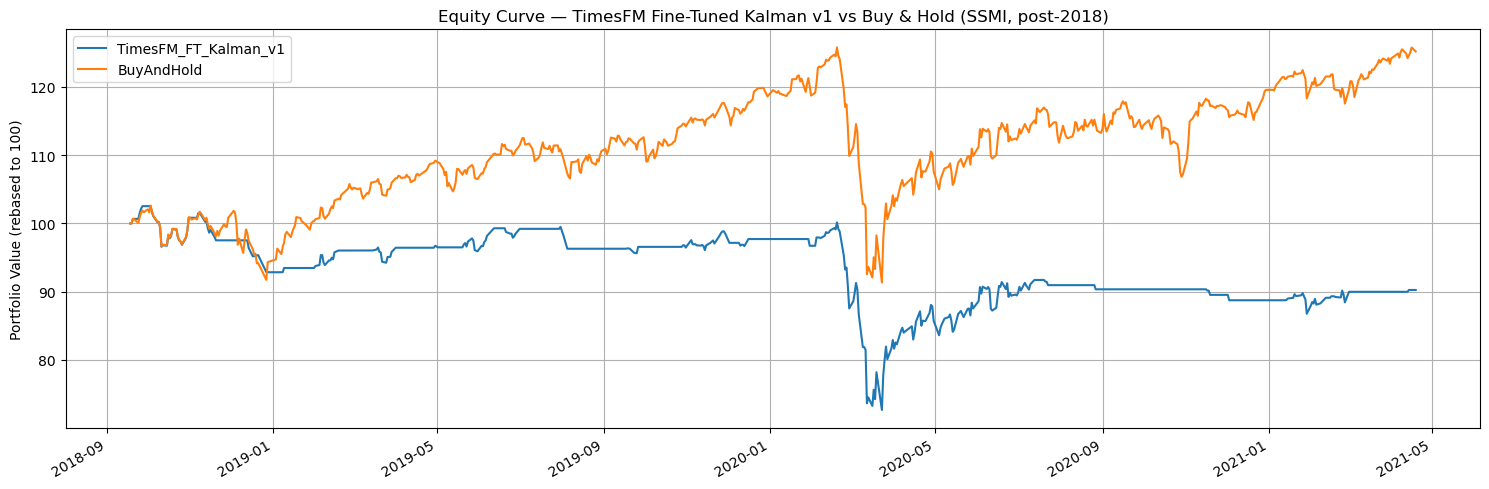

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
backtest_results.plot(ax=ax)
ax.set_title('Equity Curve — TimesFM Fine-Tuned Kalman v1 vs Buy & Hold (SSMI, post-2018)')
ax.set_ylabel('Portfolio Value (rebased to 100)')
ax.grid(True)
plt.tight_layout()
plt.show()

### 6) Monthly returns heatmap

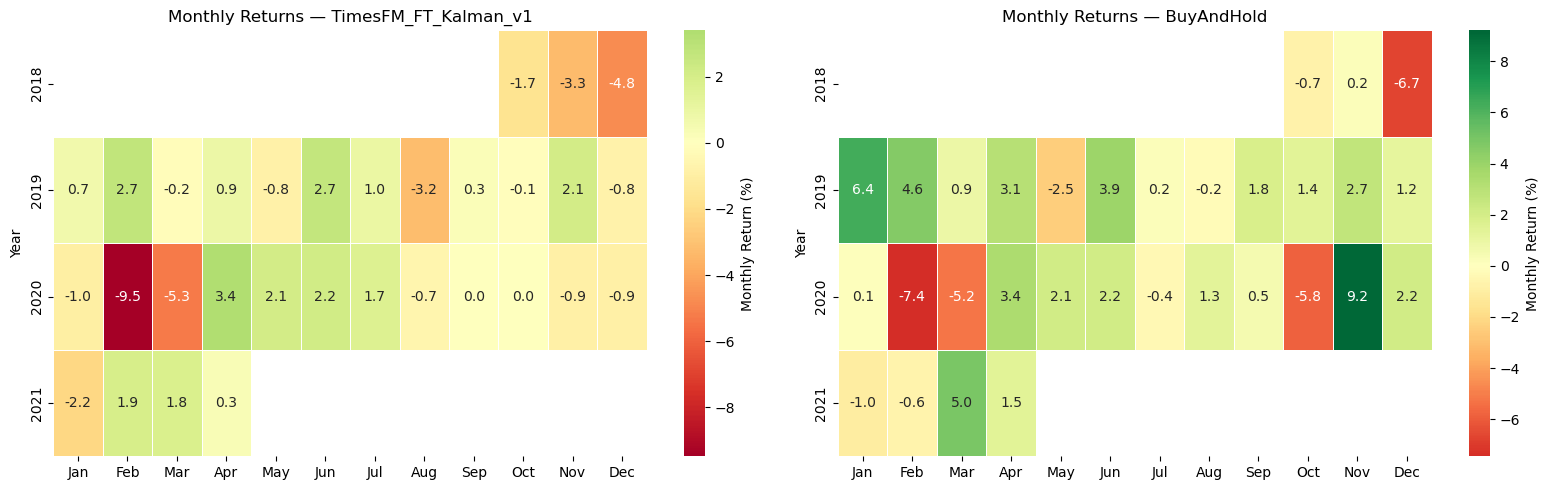

In [9]:
monthly_rets = backtest_results.prices.resample('M').last().pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col in zip(axes, monthly_rets.columns):
    pivot = monthly_rets[[col]].copy()
    pivot.index = pd.MultiIndex.from_arrays(
        [pivot.index.year, pivot.index.month], names=['Year', 'Month']
    )
    pivot = pivot[col].unstack(level='Month')
    pivot.columns = [
        'Jan','Feb','Mar','Apr','May','Jun',
        'Jul','Aug','Sep','Oct','Nov','Dec'
    ][:pivot.shape[1]]
    sns.heatmap(
        pivot * 100, annot=True, fmt='.1f', center=0,
        cmap='RdYlGn', linewidths=0.5, ax=ax,
        cbar_kws={'label': 'Monthly Return (%)'}
    )
    ax.set_title(f'Monthly Returns — {col}')

plt.tight_layout()
plt.show()